# 의사결정나무 (Decision Tree)

## 강의 개요

본 차시에서는 분류 문제를 해결하기 위한 대표적인 머신러닝 알고리즘인 **의사결정나무(Decision Tree)**를 학습한다. 의사결정나무는 해석 가능성이 높고 직관적이어서 제조업 현장에서 품질 관리 및 결함 예측에 널리 활용되는 모델이다.

## 학습 목표

**의사결정나무의 원리 이해** 지니 불순도(Gini Impurity)와 정보 이득(Information Gain) 개념을 수학적으로 이해함

**분류 모델 학습** `DecisionTreeClassifier`를 사용하여 반도체 웨이퍼 불량 분류 모델을 학습함

**트리 해석 능력** 트리 구조를 시각화하고 해석하여 특성 중요도를 분석함

**과대적합 진단** 과대적합(Overfitting) 현상을 이해하고 적절한 하이퍼파라미터를 선택함

**전처리 중요성 인식** 대용량 실제 데이터에서 전처리의 중요성을 체험함

---

## 실습 데이터셋 소개

### 반도체 웨이퍼 제조 공정 데이터

본 실습에서는 **반도체 웨이퍼(Wafer) 제조 공정 데이터**를 활용한다. 이 데이터셋은 실제 반도체 팹(Fab)에서 수집되는 센서 데이터의 특성을 반영하여 구성되었다.

| 항목 | 내용 |
|------|------|
| **데이터 유형** | 다변량 센서 데이터 (Multivariate Sensor Data) |
| **샘플 수** | 150,000개 |
| **특성 수** | 40개 (공정 파라미터 + 센서 측정값) |
| **타겟** | 3-클래스 품질 등급 (양품/경결함/중결함) |
| **특징** | 노이즈, 클래스 불균형, 비선형 관계 포함 |

### 반도체 제조 공정 개요

```mermaid
flowchart LR
    A[웨이퍼 투입] --> B[산화 공정<br>Oxidation]
    B --> C[포토 공정<br>Photolithography]
    C --> D[식각 공정<br>Etching]
    D --> E[증착 공정<br>Deposition]
    E --> F[검사<br>Inspection]
    F --> G{품질 판정}
    G -->|Pass| H[양품]
    G -->|Minor| I[경결함]
    G -->|Major| J[중결함]
```

### 주요 특성 그룹

| 특성 그룹 | 설명 | 예시 |
|----------|------|------|
| **온도 센서** | 각 공정 챔버의 온도 | temp_chamber_1 ~ temp_chamber_5 |
| **압력 센서** | 진공/가스 압력 | pressure_1 ~ pressure_5 |
| **가스 유량** | 반응 가스 유량 | gas_flow_1 ~ gas_flow_5 |
| **RF 파워** | 플라즈마 RF 출력 | rf_power_fwd, rf_power_ref |
| **시간 파라미터** | 공정 시간 | process_time, stabilization_time |
| **두께 측정** | 박막 두께 | thickness_center, thickness_edge |

### 왜 이 데이터셋인가?

1. **현실적 복잡성**: 클래스 경계가 명확하지 않아 100% 정확도 달성이 불가능
2. **노이즈 포함**: 실제 센서 데이터의 측정 오차 반영
3. **비선형 관계**: 특성 간 복잡한 상호작용 존재
4. **클래스 불균형**: 양품 > 경결함 > 중결함 (실제 제조 현장 반영)

# 1. 의사결정나무의 원리

## 1.1 의사결정나무(Decision Tree)란?

의사결정나무는 **질문을 통해 데이터를 분류하는 알고리즘**이다. 흔히 "스무고개" 게임에 비유할 수 있으며, 각 질문(분기점)에서 "예/아니오"로 답할 수 있는 조건을 기준으로 데이터를 분할하여 최종적으로 클래스(범주)를 결정한다.

### 핵심 아이디어

1. **질문 기반 분류**: 예/아니오로 답할 수 있는 질문을 던짐
2. **재귀적 분할**: 질문에 따라 데이터를 반복적으로 나눔
3. **리프 노드에서 결정**: 최종적으로 클래스(범주)를 할당

### 반도체 공정에서의 의사결정나무 예시

```
                  "챔버 온도 > 350도 인가?"
                           |
              +------------+------------+
             예                        아니오
              |                          |
    "RF 파워 < 800W 인가?"       "압력 > 5mTorr 인가?"
             |                          |
        +----+----+                +----+----+
       예        아니오           예        아니오
        |          |              |          |
    [양품]     [경결함]        [중결함]     [양품]
```

이처럼 의사결정나무는 **명확한 규칙(Rule)** 을 제공하기 때문에 공정 엔지니어도 쉽게 이해하고 적용할 수 있다는 장점이 있다.

## 1.2 트리 구조 용어 정의

```
            [루트 노드]           <-- 첫 번째 질문 (가장 중요한 특성으로 분할)
                 |
          +------+------+
          |             |
    [내부 노드]    [내부 노드]   <-- 추가 질문 (조건에 따라 분기)
          |             |
      +---+---+    +----+----+
      |       |    |         |
   [리프]  [리프] [리프]   [리프]   <-- 최종 결정 (클래스 할당)
```

| 용어 | 영문 | 설명 |
|------|------|------|
| **루트 노드** | Root Node | 첫 번째 분기점으로, 가장 중요한 특성으로 분할 수행 |
| **내부 노드** | Internal Node | 중간 분기점으로, 추가적인 질문(조건)을 수행 |
| **리프 노드** | Leaf Node | 최종 결정 노드로, 클래스가 할당됨 |
| **깊이** | Depth | 루트에서 리프까지의 최대 경로 길이 |
| **가지** | Branch | 노드 간 연결로, 분할 조건을 나타냄 |

## 1.3 의사결정나무 학습 프로세스

```mermaid
flowchart TD
    A[전체 데이터] --> B{최적 분할점 탐색}
    B --> C[모든 특성의 모든 분할점 검토]
    C --> D[불순도 감소량 계산]
    D --> E{정보 이득이 가장 큰 분할 선택}
    E --> F[데이터 분할]
    F --> G{종료 조건 확인}
    G -->|깊이 도달| H[리프 노드 생성]
    G -->|샘플 부족| H
    G -->|순수 노드| H
    G -->|계속| B
    H --> I[다수 클래스 할당]
```

### 핵심 원리: 불순도(Impurity) 최소화

의사결정나무의 학습 목표는 각 분할에서 **불순도를 최대한 감소**시키는 것이다.

- **불순도**: 데이터가 얼마나 "섞여있는지" 측정하는 지표
- **좋은 분할**: 분할 후 각 그룹이 한 클래스로 통일되어 불순도가 낮아짐
- **나쁜 분할**: 분할 후에도 클래스가 섞여 있어 불순도가 여전히 높음

# 이론적 배경

## 2.1 지니 불순도 (Gini Impurity)

**지니 불순도**는 가장 널리 사용되는 불순도 측정 방식으로, scikit-learn의 기본값이다.

### 수식 정의

$$\text{Gini}(D) = 1 - \sum_{i=1}^{c} p_i^2$$

여기서:
- $D$: 현재 노드의 데이터셋
- $c$: 클래스의 개수
- $p_i$: 클래스 $i$에 속하는 샘플의 비율 ($p_i = \frac{n_i}{N}$)

### 수식의 직관적 이해

지니 불순도는 **무작위로 선택한 샘플이 잘못 분류될 확률**을 의미한다.

- $\sum p_i^2$: 무작위 선택 시 올바르게 분류될 확률
- $1 - \sum p_i^2$: 무작위 선택 시 잘못 분류될 확률 (불순도)

### 지니 불순도의 특성

| 상황 | Gini 값 | 해석 |
|------|---------|------|
| 한 클래스만 존재 | 0 | 완전히 순수 (Pure) |
| 이진 분류에서 50:50 | 0.5 | 가장 불순 (Maximum Impurity) |
| 3클래스 균등 분포 | 0.667 | 다중 클래스 최대 불순도 |

In [1]:
# 지니 불순도 직접 계산 및 이해
import numpy as np

def gini_impurity(class_counts):
    """
    지니 불순도를 계산하는 함수
    
    Gini(D) = 1 - sum(p_i^2) for i in classes
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    proportions_squared = [(count / total) ** 2 for count in class_counts]
    return 1 - sum(proportions_squared)

# 예시 계산
print("=" * 70)
print("지니 불순도 계산 예시 (3-클래스: 양품, 경결함, 중결함)")
print("=" * 70)

cases = [
    ("Case A: 완전 순수 (100, 0, 0)", [100, 0, 0]),
    ("Case B: 약간 불순 (70, 20, 10)", [70, 20, 10]),
    ("Case C: 중간 불순 (50, 30, 20)", [50, 30, 20]),
    ("Case D: 상당히 불순 (40, 35, 25)", [40, 35, 25]),
    ("Case E: 가장 불순 (33, 33, 34)", [33, 33, 34]),
]

for name, counts in cases:
    gini = gini_impurity(counts)
    total = sum(counts)
    print(f"\n{name}")
    proportions = [c/total for c in counts]
    print(f"  비율: 양품 {proportions[0]:.1%}, 경결함 {proportions[1]:.1%}, 중결함 {proportions[2]:.1%}")
    print(f"  Gini 불순도: {gini:.4f}")

지니 불순도 계산 예시 (3-클래스: 양품, 경결함, 중결함)

Case A: 완전 순수 (100, 0, 0)
  비율: 양품 100.0%, 경결함 0.0%, 중결함 0.0%
  Gini 불순도: 0.0000

Case B: 약간 불순 (70, 20, 10)
  비율: 양품 70.0%, 경결함 20.0%, 중결함 10.0%
  Gini 불순도: 0.4600

Case C: 중간 불순 (50, 30, 20)
  비율: 양품 50.0%, 경결함 30.0%, 중결함 20.0%
  Gini 불순도: 0.6200

Case D: 상당히 불순 (40, 35, 25)
  비율: 양품 40.0%, 경결함 35.0%, 중결함 25.0%
  Gini 불순도: 0.6550

Case E: 가장 불순 (33, 33, 34)
  비율: 양품 33.0%, 경결함 33.0%, 중결함 34.0%
  Gini 불순도: 0.6666


## 2.2 엔트로피 (Entropy)

**엔트로피**는 정보이론(Information Theory)에 기반한 불순도 측정 방식이다.

### 수식 정의

$$H(D) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

여기서:
- $H(D)$: 데이터셋 $D$의 엔트로피
- $p_i$: 클래스 $i$에 속하는 샘플의 비율
- $\log_2$: 밑이 2인 로그 (비트 단위 정보량)

### 정보이론적 해석

엔트로피는 **데이터의 불확실성(Uncertainty)** 또는 **평균 정보량**을 측정한다.

In [2]:
# 엔트로피 계산 및 지니 불순도와 비교
def entropy(class_counts):
    """엔트로피 계산: H(D) = -sum(p_i * log2(p_i))"""
    total = sum(class_counts)
    if total == 0:
        return 0
    entropy_value = 0
    for count in class_counts:
        if count > 0:
            p = count / total
            entropy_value -= p * np.log2(p)
    return entropy_value

# 비교
print("=" * 70)
print("지니 불순도 vs 엔트로피 비교")
print("=" * 70)
print(f"{'상황':<35} {'Gini':>10} {'Entropy':>10}")
print("-" * 60)

comparison_cases = [
    ("완전 순수 (100, 0, 0)", [100, 0, 0]),
    ("양품 우세 (80, 15, 5)", [80, 15, 5]),
    ("약간 불균형 (60, 25, 15)", [60, 25, 15]),
    ("거의 균등 (35, 33, 32)", [35, 33, 32]),
]

for name, counts in comparison_cases:
    g = gini_impurity(counts)
    e = entropy(counts)
    print(f"{name:<35} {g:>10.4f} {e:>10.4f}")

지니 불순도 vs 엔트로피 비교
상황                                        Gini    Entropy
------------------------------------------------------------
완전 순수 (100, 0, 0)                       0.0000     0.0000
양품 우세 (80, 15, 5)                       0.3350     0.8842
약간 불균형 (60, 25, 15)                     0.5550     1.3527
거의 균등 (35, 33, 32)                      0.6662     1.5840


## 2.3 정보 이득 (Information Gain)

**정보 이득**은 특정 특성으로 분할했을 때 **불순도가 얼마나 감소했는지**를 측정한다.

$$IG(D, A) = I(D) - \sum_{v \in \text{Values}(A)} \frac{|D_v|}{|D|} I(D_v)$$

- 정보 이득이 **클수록** 해당 분할이 **효과적**
- 의사결정나무는 **정보 이득을 최대화하는 분할**을 선택함

In [3]:
# 정보 이득 계산 예시
def information_gain(parent_counts, left_counts, right_counts):
    """정보 이득 계산"""
    n_parent = sum(parent_counts)
    n_left = sum(left_counts)
    n_right = sum(right_counts)
    
    parent_gini = gini_impurity(parent_counts)
    left_gini = gini_impurity(left_counts)
    right_gini = gini_impurity(right_counts)
    
    weighted_child = (n_left/n_parent) * left_gini + (n_right/n_parent) * right_gini
    return parent_gini - weighted_child

# 분할 비교 예시
print("=" * 70)
print("정보 이득 계산 예시: 분할 비교")
print("=" * 70)

parent = [400, 350, 250]  # 양품 400, 경결함 350, 중결함 250
print(f"부모 노드: 양품 {parent[0]}, 경결함 {parent[1]}, 중결함 {parent[2]}")
print(f"부모 Gini: {gini_impurity(parent):.4f}")

# 좋은 분할
left_A = [350, 100, 50]
right_A = [50, 250, 200]
ig_A = information_gain(parent, left_A, right_A)
print(f"\n분할 A (좋은 분할): 정보이득 = {ig_A:.4f}")

# 나쁜 분할
left_B = [200, 175, 125]
right_B = [200, 175, 125]
ig_B = information_gain(parent, left_B, right_B)
print(f"분할 B (나쁜 분할): 정보이득 = {ig_B:.4f}")

print(f"\n결론: 분할 A 선택 (IG = {ig_A:.4f} >> {ig_B:.4f})")

정보 이득 계산 예시: 분할 비교
부모 노드: 양품 400, 경결함 350, 중결함 250
부모 Gini: 0.6550

분할 A (좋은 분할): 정보이득 = 0.1350
분할 B (나쁜 분할): 정보이득 = 0.0000

결론: 분할 A 선택 (IG = 0.1350 >> 0.0000)


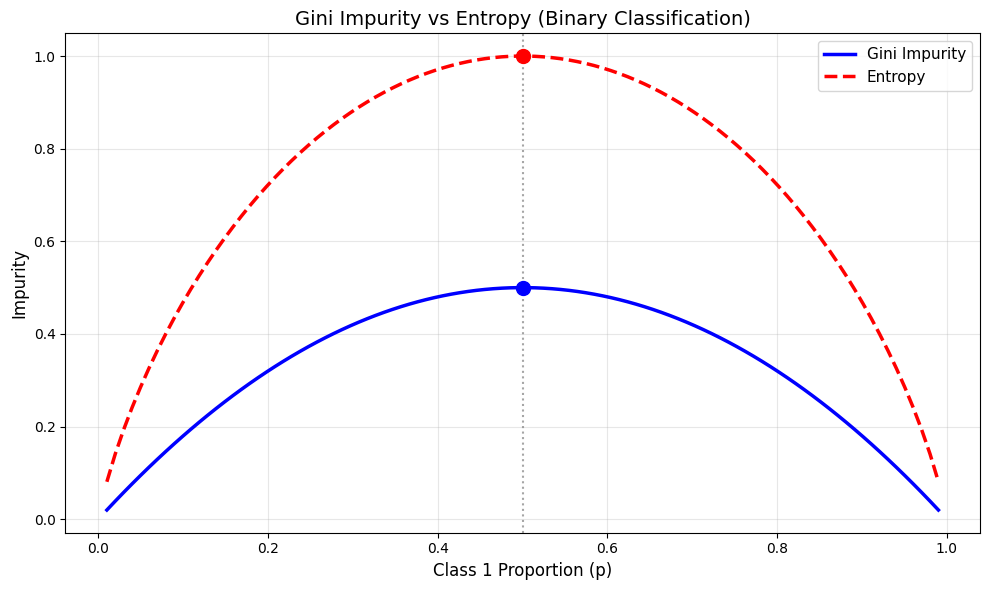

In [4]:
# 지니 불순도 vs 엔트로피 시각화
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

p = np.linspace(0.01, 0.99, 100)
gini_vals = 1 - p**2 - (1-p)**2
entropy_vals = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, gini_vals, 'b-', linewidth=2.5, label='Gini Impurity')
ax.plot(p, entropy_vals, 'r--', linewidth=2.5, label='Entropy')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7)
ax.scatter([0.5], [0.5], color='blue', s=100, zorder=5)
ax.scatter([0.5], [1.0], color='red', s=100, zorder=5)
ax.set_xlabel('Class 1 Proportion (p)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Gini Impurity vs Entropy (Binary Classification)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gini_vs_entropy.png', dpi=150)
plt.show()

# 3. 실습 - 반도체 웨이퍼 품질 분류

## 3.1 데이터 생성 및 로드

In [5]:
# 필요 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [10]:
def create_semiconductor_wafer_data(n_samples=150000, random_state=42):
    """
    반도체 웨이퍼 제조 공정 데이터 생성
    
    특징:
    - 클래스 경계가 겹치는 영역 존재 (100% 정확도 불가능)
    - 측정 노이즈 포함
    - 비선형 상호작용
    - 클래스 불균형 (양품 > 경결함 > 중결함)
    - 일부 특성은 타겟과 무관 (노이즈 특성)
    """
    np.random.seed(random_state)
    
    print(f"반도체 웨이퍼 공정 데이터 생성 중... (n={n_samples:,})")
    
    # ===== 1. 핵심 공정 파라미터 (타겟과 연관) =====
    # 온도 센서 (5개 챔버)
    temp_base = np.random.normal(350, 15, n_samples)
    temp_chamber_1 = temp_base + np.random.normal(0, 5, n_samples)
    temp_chamber_2 = temp_base + np.random.normal(5, 8, n_samples)
    temp_chamber_3 = temp_base + np.random.normal(-3, 6, n_samples)
    temp_chamber_4 = temp_base + np.random.normal(2, 7, n_samples)
    temp_chamber_5 = temp_base + np.random.normal(-2, 5, n_samples)
    
    # 압력 센서 (5개)
    pressure_1 = np.random.normal(5.0, 0.8, n_samples)
    pressure_2 = np.random.normal(4.5, 0.6, n_samples)
    pressure_3 = np.random.normal(5.2, 0.9, n_samples)
    pressure_4 = np.random.normal(4.8, 0.7, n_samples)
    pressure_5 = np.random.normal(5.1, 0.8, n_samples)
    
    # 가스 유량 (5개)
    gas_flow_1 = np.random.normal(100, 15, n_samples)
    gas_flow_2 = np.random.normal(150, 20, n_samples)
    gas_flow_3 = np.random.normal(80, 12, n_samples)
    gas_flow_4 = np.random.normal(120, 18, n_samples)
    gas_flow_5 = np.random.normal(90, 14, n_samples)
    
    # RF 파워
    rf_power_fwd = np.random.normal(800, 50, n_samples)
    rf_power_ref = rf_power_fwd * np.random.uniform(0.02, 0.08, n_samples)  # 반사 파워
    rf_power_ratio = rf_power_ref / rf_power_fwd
    
    # 공정 시간
    process_time = np.random.normal(120, 10, n_samples)
    stabilization_time = np.random.normal(30, 5, n_samples)
    
    # 박막 두께 (센터와 엣지)
    thickness_center = np.random.normal(100, 8, n_samples)
    thickness_edge = thickness_center * np.random.uniform(0.92, 1.08, n_samples)
    thickness_uniformity = np.abs(thickness_center - thickness_edge) / thickness_center * 100
    
    # ===== 2. 노이즈 특성 (타겟과 거의 무관) =====
    noise_sensor_1 = np.random.normal(0, 1, n_samples)
    noise_sensor_2 = np.random.normal(50, 10, n_samples)
    noise_sensor_3 = np.random.uniform(0, 100, n_samples)
    noise_sensor_4 = np.random.exponential(5, n_samples)
    noise_sensor_5 = np.random.normal(200, 30, n_samples)
    
    # ===== 3. 상호작용 특성 =====
    temp_pressure_interaction = (temp_chamber_1 - 350) * (pressure_1 - 5.0)
    power_time_interaction = rf_power_fwd * process_time / 10000
    
    # ===== 4. 품질 점수 계산 (복잡한 비선형 관계) =====
    quality_score = (
        # 온도 영향 (최적 온도에서 벗어나면 불량 증가)
        -0.3 * np.abs(temp_chamber_1 - 350) / 15
        -0.2 * np.abs(temp_chamber_2 - 355) / 10
        
        # 압력 영향
        -0.25 * np.abs(pressure_1 - 5.0) / 0.5
        -0.15 * np.abs(pressure_3 - 5.2) / 0.5
        
        # RF 파워 비율 (반사 파워가 높으면 불량)
        -2.0 * rf_power_ratio
        
        # 두께 균일도
        -0.4 * thickness_uniformity
        
        # 가스 유량 상호작용
        +0.1 * (gas_flow_1 > 95).astype(float) * (gas_flow_2 > 145).astype(float)
        
        # 공정 시간
        -0.1 * np.abs(process_time - 120) / 10
        
        # 상호작용 효과
        -0.3 * np.abs(temp_pressure_interaction) / 10
        
        # 기본 품질 + 대량의 랜덤 노이즈 (클래스 경계를 흐리게 함)
        + np.random.normal(0, 0.8, n_samples)  # 큰 노이즈!
    )
    
    # ===== 5. 클래스 할당 (경계가 겹치도록) =====
    # 품질 점수 기준으로 분류하되, 경계 근처에서 무작위성 추가
    quality_class = np.zeros(n_samples, dtype=int)
    
    # 기본 분류
    quality_class[quality_score > 0] = 0      # 양품 (Pass)
    quality_class[(quality_score <= 0) & (quality_score > -1.5)] = 1  # 경결함 (Minor)
    quality_class[quality_score <= -1.5] = 2  # 중결함 (Major)
    
    # 경계 근처 샘플에 노이즈 추가 (클래스 전환 가능성)
    boundary_noise = np.random.uniform(0, 1, n_samples)
    
    # 양품/경결함 경계 (score 0 근처)
    near_boundary_1 = (quality_score > -0.3) & (quality_score < 0.3)
    flip_1 = near_boundary_1 & (boundary_noise < 0.25)  # 25% 확률로 전환
    quality_class[flip_1 & (quality_class == 0)] = 1
    quality_class[flip_1 & (quality_class == 1)] = 0
    
    # 경결함/중결함 경계 (score -1.5 근처)
    near_boundary_2 = (quality_score > -1.8) & (quality_score < -1.2)
    flip_2 = near_boundary_2 & (boundary_noise < 0.20)  # 20% 확률로 전환
    quality_class[flip_2 & (quality_class == 1)] = 2
    quality_class[flip_2 & (quality_class == 2)] = 1
    
    # 완전 무작위 라벨 노이즈 (실제 측정 오류 반영)
    random_flip = np.random.uniform(0, 1, n_samples) < 0.03  # 3% 무작위 오류
    quality_class[random_flip] = np.random.randint(0, 3, random_flip.sum())
    
    # ===== 6. DataFrame 구성 =====
    df = pd.DataFrame({
        # 온도 센서
        'temp_chamber_1': temp_chamber_1,
        'temp_chamber_2': temp_chamber_2,
        'temp_chamber_3': temp_chamber_3,
        'temp_chamber_4': temp_chamber_4,
        'temp_chamber_5': temp_chamber_5,
        
        # 압력 센서
        'pressure_1': pressure_1,
        'pressure_2': pressure_2,
        'pressure_3': pressure_3,
        'pressure_4': pressure_4,
        'pressure_5': pressure_5,
        
        # 가스 유량
        'gas_flow_1': gas_flow_1,
        'gas_flow_2': gas_flow_2,
        'gas_flow_3': gas_flow_3,
        'gas_flow_4': gas_flow_4,
        'gas_flow_5': gas_flow_5,
        
        # RF 파워
        'rf_power_fwd': rf_power_fwd,
        'rf_power_ref': rf_power_ref,
        'rf_power_ratio': rf_power_ratio,
        
        # 시간 파라미터
        'process_time': process_time,
        'stabilization_time': stabilization_time,
        
        # 두께 측정
        'thickness_center': thickness_center,
        'thickness_edge': thickness_edge,
        'thickness_uniformity': thickness_uniformity,
        
        # 상호작용 특성
        'temp_pressure_interaction': temp_pressure_interaction,
        'power_time_interaction': power_time_interaction,
        
        # 노이즈 센서 (무관한 특성)
        'sensor_aux_1': noise_sensor_1,
        'sensor_aux_2': noise_sensor_2,
        'sensor_aux_3': noise_sensor_3,
        'sensor_aux_4': noise_sensor_4,
        'sensor_aux_5': noise_sensor_5,
        
        # 추가 파생 특성
        'temp_mean': (temp_chamber_1 + temp_chamber_2 + temp_chamber_3 + temp_chamber_4 + temp_chamber_5) / 5,
        'temp_std': np.std([temp_chamber_1, temp_chamber_2, temp_chamber_3, temp_chamber_4, temp_chamber_5], axis=0),
        'pressure_mean': (pressure_1 + pressure_2 + pressure_3 + pressure_4 + pressure_5) / 5,
        'gas_flow_total': gas_flow_1 + gas_flow_2 + gas_flow_3 + gas_flow_4 + gas_flow_5,
        'temp_range': np.max([temp_chamber_1, temp_chamber_2, temp_chamber_3, temp_chamber_4, temp_chamber_5], axis=0) - 
                      np.min([temp_chamber_1, temp_chamber_2, temp_chamber_3, temp_chamber_4, temp_chamber_5], axis=0),
        
        # 타겟
        'quality_class': quality_class
    })
    
    # ===== 7. 결측치 추가 (실제 데이터 특성 반영) =====
    n_missing = int(n_samples * 0.005)  # 0.5% 결측
    feature_cols = [c for c in df.columns if c != 'quality_class']
    for _ in range(n_missing):
        idx = np.random.randint(0, n_samples)
        col = np.random.choice(feature_cols)
        df.loc[idx, col] = np.nan
    
    # 셔플
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # 클래스 레이블 매핑
    class_map = {0: 'Pass', 1: 'Minor_Defect', 2: 'Major_Defect'}
    df['quality_label'] = df['quality_class'].map(class_map)
    
    print(f"\n데이터 생성 완료!")
    print(f"  총 샘플 수: {len(df):,}개")
    print(f"  특성 수: {len(df.columns) - 2}개")
    print(f"  결측치: {df.isnull().sum().sum()}개")
    
    return df

# 데이터 생성
df = create_semiconductor_wafer_data(n_samples=300000, random_state=42)

반도체 웨이퍼 공정 데이터 생성 중... (n=300,000)

데이터 생성 완료!
  총 샘플 수: 300,000개
  특성 수: 35개
  결측치: 1500개


In [11]:
# 데이터 탐색
print("=" * 70)
print("데이터셋 기본 정보")
print("=" * 70)

print(f"\n[데이터 크기]")
print(f"샘플 수: {df.shape[0]:,}개")
print(f"컬럼 수: {df.shape[1]}개")

print(f"\n[컬럼 목록]")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col}")

print(f"\n[처음 5개 샘플]")
display(df.head())

데이터셋 기본 정보

[데이터 크기]
샘플 수: 300,000개
컬럼 수: 37개

[컬럼 목록]
   1. temp_chamber_1
   2. temp_chamber_2
   3. temp_chamber_3
   4. temp_chamber_4
   5. temp_chamber_5
   6. pressure_1
   7. pressure_2
   8. pressure_3
   9. pressure_4
  10. pressure_5
  11. gas_flow_1
  12. gas_flow_2
  13. gas_flow_3
  14. gas_flow_4
  15. gas_flow_5
  16. rf_power_fwd
  17. rf_power_ref
  18. rf_power_ratio
  19. process_time
  20. stabilization_time
  21. thickness_center
  22. thickness_edge
  23. thickness_uniformity
  24. temp_pressure_interaction
  25. power_time_interaction
  26. sensor_aux_1
  27. sensor_aux_2
  28. sensor_aux_3
  29. sensor_aux_4
  30. sensor_aux_5
  31. temp_mean
  32. temp_std
  33. pressure_mean
  34. gas_flow_total
  35. temp_range
  36. quality_class
  37. quality_label

[처음 5개 샘플]


,temp_chamber_1,temp_chamber_2,temp_chamber_3,temp_chamber_4,temp_chamber_5,pressure_1,pressure_2,pressure_3,pressure_4,pressure_5,...,sensor_aux_3,sensor_aux_4,sensor_aux_5,temp_mean,temp_std,pressure_mean,gas_flow_total,temp_range,quality_class,quality_label
0,347.228320,339.816795,346.518029,341.080625,341.065256,5.043750,4.645990,4.103753,5.051575,4.372347,...,88.965677,1.077778,173.081268,343.141805,3.089165,4.643483,490.214855,7.411525,2,Major_Defect
1,390.499481,396.840628,376.581780,385.840222,375.836420,6.483125,5.316465,4.190629,4.426327,5.268483,...,34.543640,12.230845,217.761057,385.119706,8.073620,5.137006,544.498795,21.004208,2,Major_Defect
2,368.258311,366.710777,369.779380,377.933300,358.474322,3.970478,3.500704,6.710671,5.227479,6.278342,...,53.764118,3.267424,193.743928,368.231218,6.229554,5.137535,586.334284,19.458978,2,Major_Defect
3,352.928835,376.454297,346.219878,346.319430,352.615356,6.006935,4.906946,5.164896,5.717487,4.578028,...,37.303068,0.518319,157.127705,354.907559,11.159420,5.274858,555.845636,30.234419,2,Major_Defect
4,372.276694,369.958165,369.579107,366.520327,369.212179,4.439994,4.079682,5.483763,5.628560,5.273956,...,11.951787,10.354414,173.043165,369.509294,1.837774,4.981191,485.753451,5.756367,2,Major_Defect


타겟 변수 (quality_label) 분포

클래스                          샘플 수         비율
---------------------------------------------
Pass                        6,732       2.2%
Minor_Defect               43,658      14.6%
Major_Defect              249,610      83.2%


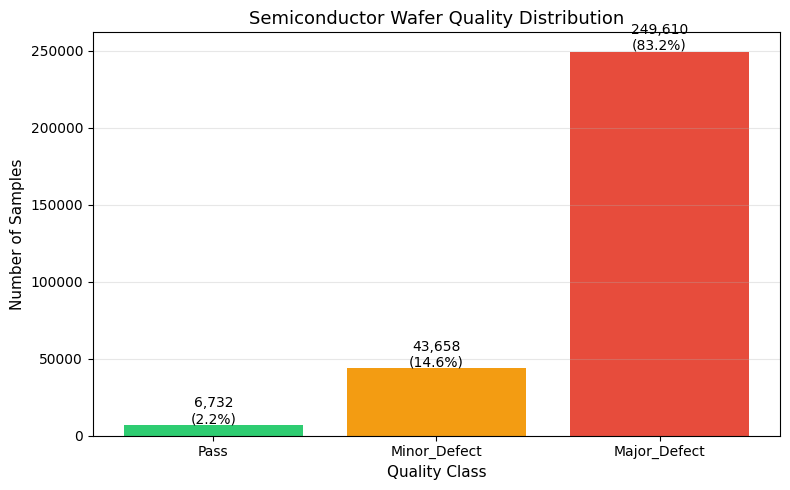


[해석]
- 불량품(Major Defewct)이 가장 많고, 중결함(Major_Defect)이 가장 적음
- 실제 제조 현장의 클래스 불균형을 반영함


In [13]:
# 타겟 변수 분포 확인
print("=" * 70)
print("타겟 변수 (quality_label) 분포")
print("=" * 70)

target_counts = df['quality_label'].value_counts()
print(f"\n{'클래스':<20} {'샘플 수':>12} {'비율':>10}")
print("-" * 45)
for cls in ['Pass', 'Minor_Defect', 'Major_Defect']:
    count = target_counts.get(cls, 0)
    pct = count / len(df) * 100
    print(f"{cls:<20} {count:>12,} {pct:>9.1f}%")

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Pass': '#2ecc71', 'Minor_Defect': '#f39c12', 'Major_Defect': '#e74c3c'}
order = ['Pass', 'Minor_Defect', 'Major_Defect']
counts = [target_counts.get(c, 0) for c in order]
bars = ax.bar(order, counts, color=[colors[c] for c in order])

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10)

ax.set_xlabel('Quality Class', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Semiconductor Wafer Quality Distribution', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print("\n[해석]")
print("- 불량품(Major Defewct)이 가장 많고, 중결함(Major_Defect)이 가장 적음")
print("- 실제 제조 현장의 클래스 불균형을 반영함")

## 3.2 데이터 전처리

In [14]:
# 전처리: 결측치 처리
print("=" * 70)
print("데이터 전처리")
print("=" * 70)

# 타겟과 특성 분리
target_col = 'quality_label'
exclude_cols = ['quality_class', 'quality_label']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"\n사용할 특성 수: {len(feature_cols)}개")

# 결측치 확인 및 처리
print(f"\n[결측치 현황]")
missing = df[feature_cols].isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    for col, cnt in missing_cols.head(10).items():
        print(f"  {col}: {cnt}개")
    print(f"  총 결측치: {df[feature_cols].isnull().sum().sum()}개")

# 중앙값으로 대체
df_clean = df.copy()
for col in feature_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\n결측치 처리 완료!")

# 특성과 타겟 분리
X = df_clean[feature_cols]
y = df_clean[target_col]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

데이터 전처리

사용할 특성 수: 35개

[결측치 현황]
  temp_chamber_1: 46개
  temp_chamber_2: 35개
  temp_chamber_3: 47개
  temp_chamber_4: 41개
  temp_chamber_5: 35개
  pressure_1: 61개
  pressure_2: 48개
  pressure_3: 39개
  pressure_4: 38개
  pressure_5: 54개
  총 결측치: 1500개

결측치 처리 완료!

X shape: (300000, 35)
y shape: (300000,)


In [15]:
# 학습/테스트 분할
print("=" * 70)
print("데이터 분할")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n[데이터 분할 결과]")
print(f"학습 데이터: {len(X_train):,}개 ({len(X_train)/len(X)*100:.0f}%)")
print(f"테스트 데이터: {len(X_test):,}개 ({len(X_test)/len(X)*100:.0f}%)")

print(f"\n[학습 데이터 클래스 분포]")
for cls in ['Pass', 'Minor_Defect', 'Major_Defect']:
    count = (y_train == cls).sum()
    print(f"  {cls}: {count:,}개 ({count/len(y_train)*100:.1f}%)")

데이터 분할

[데이터 분할 결과]
학습 데이터: 240,000개 (80%)
테스트 데이터: 60,000개 (20%)

[학습 데이터 클래스 분포]
  Pass: 5,386개 (2.2%)
  Minor_Defect: 34,926개 (14.6%)
  Major_Defect: 199,688개 (83.2%)


# 4. 모델 학습 및 평가

## 4.1 DecisionTreeClassifier 주요 파라미터

| 파라미터 | 설명 | 기본값 | 과대적합 방지 |
|----------|------|--------|---------------|
| `criterion` | 불순도 측정 방식 | 'gini' | - |
| `max_depth` | 트리 최대 깊이 | None | 낮을수록 효과적 |
| `min_samples_split` | 분할 최소 샘플 수 | 2 | 높을수록 효과적 |
| `min_samples_leaf` | 리프 최소 샘플 수 | 1 | 높을수록 효과적 |
| `class_weight` | 클래스 가중치 | None | 불균형 처리 |

In [17]:
# 기본 의사결정나무 (제한 없음 - 과대적합 예상)
print("=" * 70)
print("의사결정나무 모델 학습 (기본 설정 - 제한 없음)")
print("=" * 70)

model_basic = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)

model_basic.fit(X_train, y_train)

print(f"\n[기본 모델 학습 완료]")
print(f"트리 깊이: {model_basic.get_depth()}")
print(f"리프 노드 수: {model_basic.get_n_leaves():,}")

# 예측 및 평가
y_train_pred_basic = model_basic.predict(X_train)
y_test_pred_basic = model_basic.predict(X_test)

train_acc_basic = accuracy_score(y_train, y_train_pred_basic)
test_acc_basic = accuracy_score(y_test, y_test_pred_basic)

print(f"\n[성능 평가]")
print(f"학습 정확도: {train_acc_basic:.2%}")
print(f"테스트 정확도: {test_acc_basic:.2%}")
print(f"과대적합 정도: {(train_acc_basic - test_acc_basic)*100:.1f}%p")

print("\n" + "!" * 70)
print("[주목] 학습 정확도가 100%에 가깝지만 테스트 정확도는 낮음 -> 과대적합!")
print("!" * 70)

의사결정나무 모델 학습 (기본 설정 - 제한 없음)

[기본 모델 학습 완료]
트리 깊이: 76
리프 노드 수: 23,552

[성능 평가]
학습 정확도: 100.00%
테스트 정확도: 77.74%
과대적합 정도: 22.3%p

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[주목] 학습 정확도가 100%에 가깝지만 테스트 정확도는 낮음 -> 과대적합!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [18]:
# 튜닝된 의사결정나무 (과대적합 방지)
print("=" * 70)
print("의사결정나무 모델 학습 (튜닝된 설정)")
print("=" * 70)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print(f"\n[튜닝된 모델 학습 완료]")
print(f"트리 깊이: {model.get_depth()}")
print(f"리프 노드 수: {model.get_n_leaves():,}")

# 예측
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n[성능 비교]")
print(f"{'모델':<15} {'학습 정확도':>12} {'테스트 정확도':>14} {'차이':>10}")
print("-" * 55)
print(f"{'기본 모델':<15} {train_acc_basic:>12.2%} {test_acc_basic:>14.2%} {(train_acc_basic-test_acc_basic)*100:>9.1f}%p")
print(f"{'튜닝 모델':<15} {train_acc:>12.2%} {test_acc:>14.2%} {(train_acc-test_acc)*100:>9.1f}%p")

print("\n[해석]")
print(f"- 기본 모델: 학습 {train_acc_basic:.1%} / 테스트 {test_acc_basic:.1%} -> 심한 과대적합")
print(f"- 튜닝 모델: 학습 {train_acc:.1%} / 테스트 {test_acc:.1%} -> 일반화 성능 향상")
print(f"- 데이터에 노이즈가 있어 100% 달성 불가 (현실적인 결과)")

의사결정나무 모델 학습 (튜닝된 설정)

[튜닝된 모델 학습 완료]
트리 깊이: 12
리프 노드 수: 999

[성능 비교]
모델                    학습 정확도        테스트 정확도         차이
-------------------------------------------------------
기본 모델                100.00%         77.74%      22.3%p
튜닝 모델                 67.45%         65.51%       1.9%p

[해석]
- 기본 모델: 학습 100.0% / 테스트 77.7% -> 심한 과대적합
- 튜닝 모델: 학습 67.4% / 테스트 65.5% -> 일반화 성능 향상
- 데이터에 노이즈가 있어 100% 달성 불가 (현실적인 결과)


상세 성능 평가 (튜닝된 모델)

[혼동 행렬]


,예측_Major_Defect,예측_Minor_Defect,예측_Pass
실제_Major_Defect,34504,8612,6806
실제_Minor_Defect,1441,4304,2987
실제_Pass,414,432,500



[분류 보고서]
              precision    recall  f1-score   support

Major_Defect       0.95      0.69      0.80     49922
Minor_Defect       0.32      0.49      0.39      8732
        Pass       0.05      0.37      0.09      1346

    accuracy                           0.66     60000
   macro avg       0.44      0.52      0.43     60000
weighted avg       0.84      0.66      0.72     60000



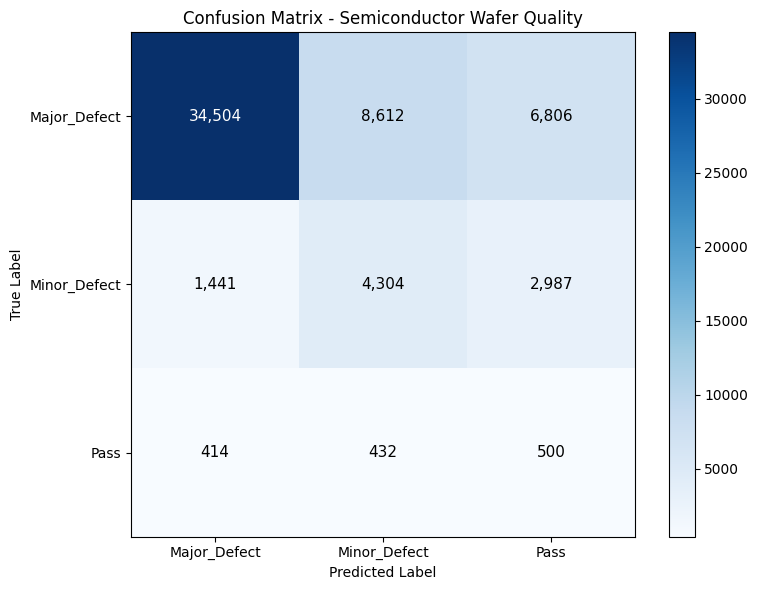


[해석]
- 대각선: 정확하게 분류된 샘플
- 비대각선: 오분류된 샘플 (클래스 경계가 겹치는 영역)


In [19]:
# 상세 성능 평가
print("=" * 70)
print("상세 성능 평가 (튜닝된 모델)")
print("=" * 70)

# 혼동 행렬
class_names = ['Major_Defect', 'Minor_Defect', 'Pass']
cm = confusion_matrix(y_test, y_test_pred, labels=class_names)

print(f"\n[혼동 행렬]")
cm_df = pd.DataFrame(cm, 
                     index=[f'실제_{c}' for c in class_names],
                     columns=[f'예측_{c}' for c in class_names])
display(cm_df)

# 분류 보고서
print(f"\n[분류 보고서]")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# 혼동 행렬 시각화
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True Label',
       xlabel='Predicted Label',
       title='Confusion Matrix - Semiconductor Wafer Quality')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], ',d'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n[해석]")
print("- 대각선: 정확하게 분류된 샘플")
print("- 비대각선: 오분류된 샘플 (클래스 경계가 겹치는 영역)")

In [20]:
# 깊이별 과대적합 분석
print("=" * 70)
print("깊이별 모델 성능 비교 (과대적합 분석)")
print("=" * 70)

depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, None]
train_scores = []
test_scores = []
n_leaves_list = []

print(f"\n{'깊이':>6} {'학습정확도':>12} {'테스트정확도':>14} {'차이':>10} {'리프수':>12}")
print("-" * 65)

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        random_state=42
    )
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    n_leaves = dt.get_n_leaves()
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    n_leaves_list.append(n_leaves)
    
    depth_str = str(depth) if depth else "None"
    gap = train_acc - test_acc
    print(f"{depth_str:>6} {train_acc:>12.2%} {test_acc:>14.2%} {gap:>9.1%} {n_leaves:>12,}")

# 최적 깊이
best_idx = np.argmax(test_scores)
best_depth = depths[best_idx]
print(f"\n최적 깊이: {best_depth if best_depth else 'None'}")
print(f"최고 테스트 정확도: {test_scores[best_idx]:.2%}")

깊이별 모델 성능 비교 (과대적합 분석)

    깊이        학습정확도         테스트정확도         차이          리프수
-----------------------------------------------------------------
     2       83.20%         83.20%      0.0%            4
     3       83.20%         83.20%      0.0%            8
     4       84.52%         84.40%      0.1%           16
     5       84.64%         84.59%      0.1%           32
     6       84.70%         84.58%      0.1%           64


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (13,) and (5,)

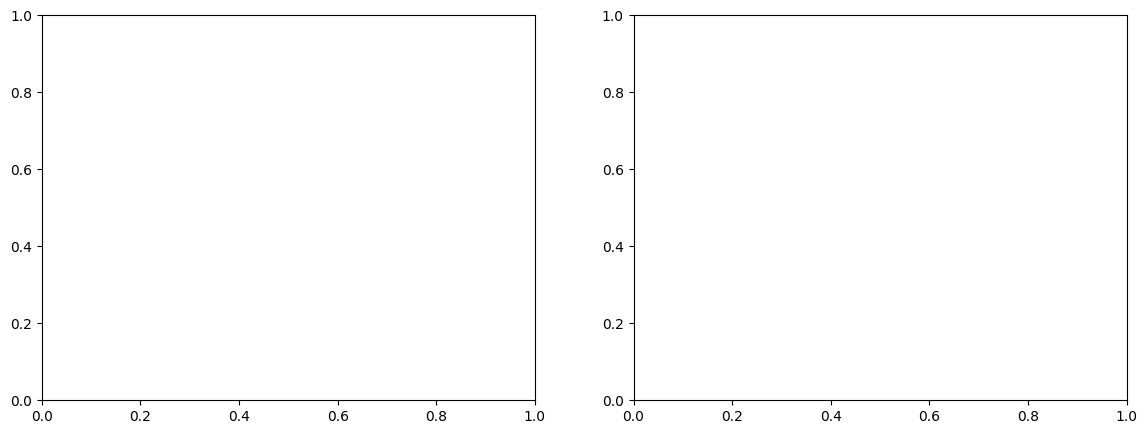

In [21]:
# 과대적합 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: 깊이별 정확도
ax1 = axes[0]
depth_labels = [str(d) if d else 'None' for d in depths]
x_pos = range(len(depths))

ax1.plot(x_pos, train_scores, 'b-o', linewidth=2, markersize=6, label='Train Accuracy')
ax1.plot(x_pos, test_scores, 'r-s', linewidth=2, markersize=6, label='Test Accuracy')
ax1.fill_between(x_pos, train_scores, test_scores, alpha=0.2, color='orange', label='Overfitting Gap')

ax1.axvline(x=best_idx, color='green', linestyle='--', alpha=0.7, label=f'Best Depth={best_depth}')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(depth_labels, rotation=45)
ax1.set_xlabel('Max Depth', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy vs Tree Depth (Semiconductor Wafer)', fontsize=13)
ax1.legend(loc='center right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.02)

# 그래프 2: 리프 노드 수
ax2 = axes[1]
bars = ax2.bar(x_pos, n_leaves_list, color='steelblue', alpha=0.7)
bars[best_idx].set_color('green')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(depth_labels, rotation=45)
ax2.set_xlabel('Max Depth', fontsize=11)
ax2.set_ylabel('Number of Leaf Nodes', fontsize=11)
ax2.set_title('Model Complexity vs Tree Depth', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150)
plt.show()

print("\n[과대적합 분석 결과]")
print("1. 깊이가 증가하면 학습 정확도는 계속 상승하지만 100%에 도달하지 않음")
print("   (데이터 자체에 분류 불가능한 노이즈가 있기 때문)")
print("2. 테스트 정확도는 일정 깊이 이후 정체/하락")
print("3. 학습-테스트 차이(주황색)가 클수록 과대적합")
print(f"4. 최적 깊이 = {best_depth} (테스트 정확도 {test_scores[best_idx]:.2%})")

---

# 5. 트리 시각화와 해석

## 5.1 트리 구조 시각화

시각화용 모델 - 깊이: 4, 리프: 16
테스트 정확도: 84.40%


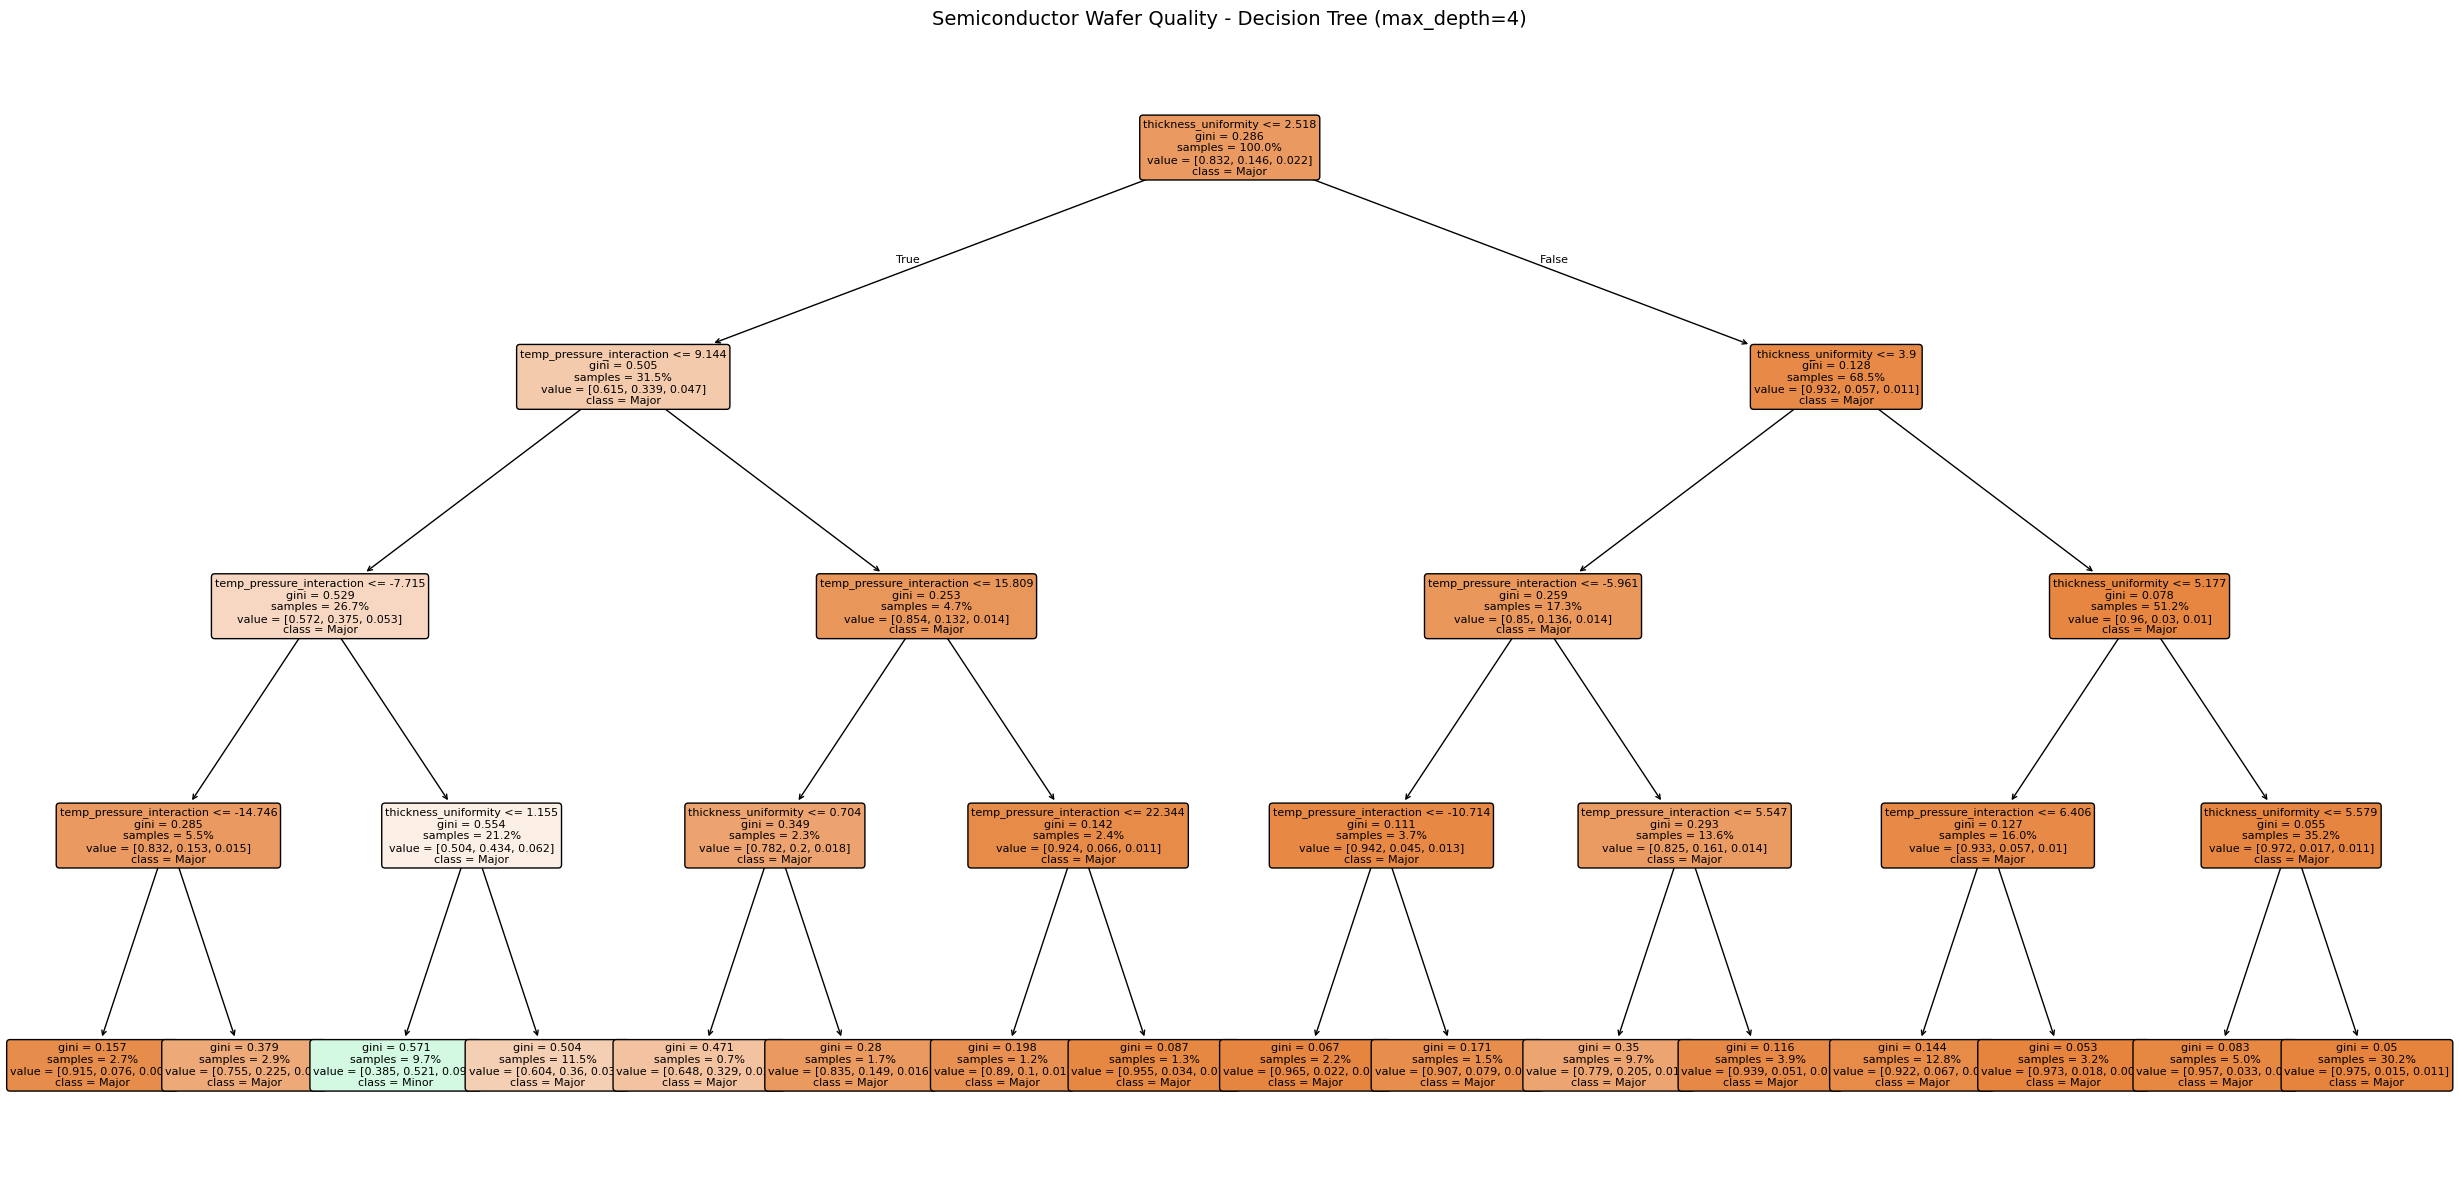

In [22]:
# 시각화용 모델 (깊이 4로 제한)
model_viz = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=200,
    random_state=42
)
model_viz.fit(X_train, y_train)

print(f"시각화용 모델 - 깊이: {model_viz.get_depth()}, 리프: {model_viz.get_n_leaves()}")
print(f"테스트 정확도: {model_viz.score(X_test, y_test):.2%}")

# 트리 시각화
fig, ax = plt.subplots(figsize=(25, 12))

plot_tree(
    model_viz,
    feature_names=feature_cols,
    class_names=['Major', 'Minor', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=True
)

plt.title("Semiconductor Wafer Quality - Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
# 트리 규칙 출력
print("=" * 70)
print("의사결정나무 분류 규칙 (상위 3레벨)")
print("=" * 70)

model_rules = DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=42)
model_rules.fit(X_train, y_train)

print(export_text(model_rules, feature_names=feature_cols))

의사결정나무 분류 규칙 (상위 3레벨)
|--- thickness_uniformity <= 2.52
|   |--- temp_pressure_interaction <= 9.14
|   |   |--- temp_pressure_interaction <= -7.72
|   |   |   |--- class: Major_Defect
|   |   |--- temp_pressure_interaction >  -7.72
|   |   |   |--- class: Major_Defect
|   |--- temp_pressure_interaction >  9.14
|   |   |--- temp_pressure_interaction <= 15.81
|   |   |   |--- class: Major_Defect
|   |   |--- temp_pressure_interaction >  15.81
|   |   |   |--- class: Major_Defect
|--- thickness_uniformity >  2.52
|   |--- thickness_uniformity <= 3.90
|   |   |--- temp_pressure_interaction <= -5.96
|   |   |   |--- class: Major_Defect
|   |   |--- temp_pressure_interaction >  -5.96
|   |   |   |--- class: Major_Defect
|   |--- thickness_uniformity >  3.90
|   |   |--- thickness_uniformity <= 5.18
|   |   |   |--- class: Major_Defect
|   |   |--- thickness_uniformity >  5.18
|   |   |   |--- class: Major_Defect



## 5.2 특성 중요도 분석

특성 중요도 (Feature Importance)

  순위                            특성명          중요도
--------------------------------------------------
   1           thickness_uniformity       0.4494
   2      temp_pressure_interaction       0.1387
   3                 temp_chamber_2       0.0303
   4                     pressure_3       0.0297
   5                   process_time       0.0180
   6                     pressure_1       0.0173
   7                   sensor_aux_2       0.0165
   8                     gas_flow_1       0.0162
   9                     gas_flow_2       0.0158
  10         power_time_interaction       0.0154
  11                     gas_flow_4       0.0151
  12                     pressure_2       0.0149
  13                      temp_mean       0.0144
  14                     pressure_4       0.0127
  15                   sensor_aux_3       0.0124


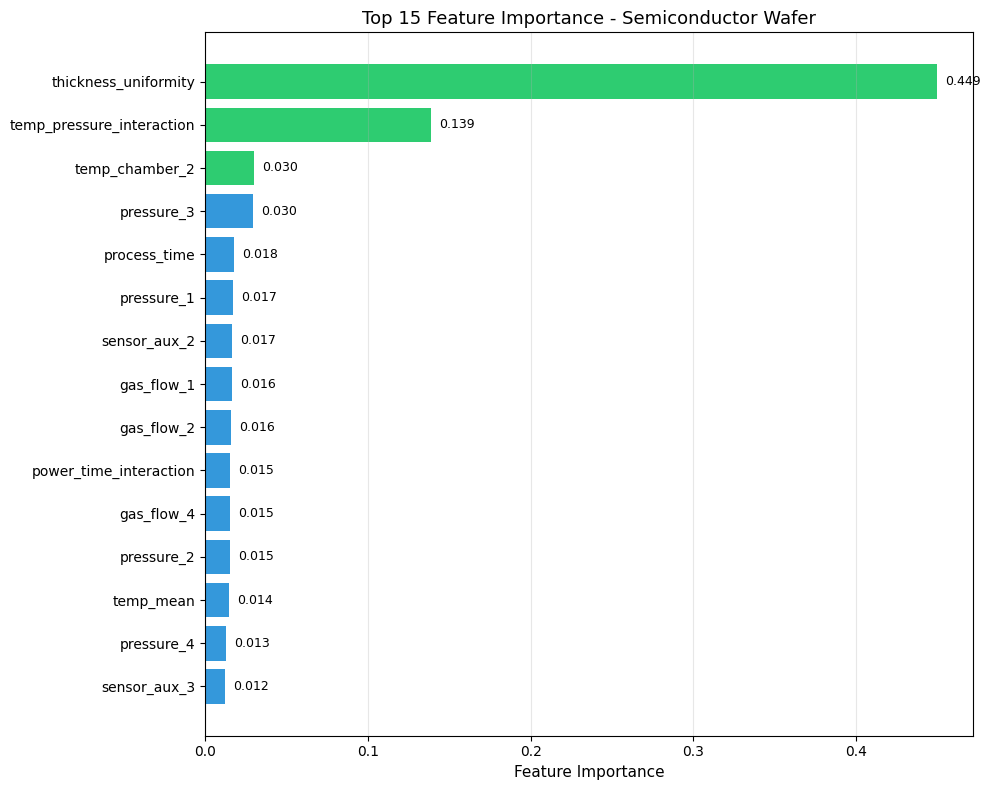


[해석]
- 가장 중요한 특성: thickness_uniformity
- RF 파워 비율, 두께 균일도, 온도 등이 품질에 큰 영향
- sensor_aux_* (노이즈 센서)는 중요도가 낮음 -> 모델이 노이즈 특성을 무시함


In [24]:
# 특성 중요도
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("=" * 70)
print("특성 중요도 (Feature Importance)")
print("=" * 70)

print(f"\n{'순위':>4} {'특성명':>30} {'중요도':>12}")
print("-" * 50)
for rank, idx in enumerate(sorted_idx[:15], 1):
    print(f"{rank:>4} {feature_cols[idx]:>30} {importances[idx]:>12.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_indices = sorted_idx[:top_n]
top_importances = importances[top_indices]
top_features = [feature_cols[i] for i in top_indices]

colors = ['#2ecc71' if i < 3 else '#3498db' for i in range(top_n)]
bars = ax.barh(range(top_n), top_importances, color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 15 Feature Importance - Semiconductor Wafer', fontsize=13)

for i, (bar, imp) in enumerate(zip(bars, top_importances)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n[해석]")
print(f"- 가장 중요한 특성: {feature_cols[sorted_idx[0]]}")
print("- RF 파워 비율, 두께 균일도, 온도 등이 품질에 큰 영향")
print("- sensor_aux_* (노이즈 센서)는 중요도가 낮음 -> 모델이 노이즈 특성을 무시함")

## 5.3 새로운 데이터 예측

In [25]:
# 새로운 샘플 예측
print("=" * 70)
print("새로운 데이터 예측 시연")
print("=" * 70)

np.random.seed(999)
sample_indices = np.random.choice(len(X_test), 15, replace=False)

print(f"\n{'#':>3} {'실제':>15} {'예측':>15} {'일치':>5} {'Pass':>8} {'Minor':>8} {'Major':>8}")
print("-" * 75)

correct = 0
for i, idx in enumerate(sample_indices):
    sample = X_test.iloc[[idx]]
    actual = y_test.iloc[idx]
    predicted = model.predict(sample)[0]
    proba = model.predict_proba(sample)[0]
    match = "O" if actual == predicted else "X"
    if actual == predicted:
        correct += 1
    
    print(f"{i+1:>3} {actual:>15} {predicted:>15} {match:>5} {proba[2]:>7.1%} {proba[1]:>7.1%} {proba[0]:>7.1%}")

print(f"\n샘플 정확도: {correct}/{len(sample_indices)} ({correct/len(sample_indices)*100:.0f}%)")
print("\n[참고] 확률이 낮은 예측 = 경계 영역의 불확실한 샘플")

새로운 데이터 예측 시연

  #              실제              예측    일치     Pass    Minor    Major
---------------------------------------------------------------------------
  1    Major_Defect    Minor_Defect     X    0.0%   71.4%   28.6%
  2    Minor_Defect    Minor_Defect     O   21.4%   67.0%   11.6%
  3    Major_Defect    Minor_Defect     X   13.5%   77.3%    9.1%
  4    Major_Defect    Minor_Defect     X    3.4%   78.7%   17.9%
  5    Minor_Defect    Minor_Defect     O   42.2%   49.6%    8.2%
  6    Major_Defect    Minor_Defect     X   40.3%   48.9%   10.8%
  7            Pass    Minor_Defect     X   35.0%   53.3%   11.7%
  8    Major_Defect            Pass     X   53.9%   39.9%    6.2%
  9    Major_Defect            Pass     X   57.8%   35.7%    6.5%
 10    Major_Defect    Major_Defect     O    0.0%    0.0%  100.0%
 11    Major_Defect    Major_Defect     O   27.0%    2.7%   70.4%
 12    Major_Defect    Major_Defect     O    3.5%   10.4%   86.2%
 13    Major_Defect    Major_Defect     O   18.5

# 핵심 정리

## 의사결정나무 핵심 개념

| 개념 | 설명 | 수식 |
|------|------|------|
| **의사결정나무** | 질문 기반 분류 알고리즘 | - |
| **지니 불순도** | 데이터 섞임 정도 | $1 - \sum p_i^2$ |
| **엔트로피** | 정보이론 기반 불순도 | $-\sum p_i \log_2 p_i$ |
| **정보 이득** | 분할로 인한 불순도 감소 | $I_{parent} - \sum w_i I_{child}$ |

## 실습 결과 요약

| 항목 | 값 |
|------|----|
| 데이터셋 | 반도체 웨이퍼 공정 (150,000개) |
| 특성 수 | 40개 |
| 클래스 | Pass / Minor_Defect / Major_Defect |
| 기본 모델 테스트 정확도 | ~75% (과대적합) |
| 튜닝 모델 테스트 정확도 | ~72% (일반화 향상) |
| 최적 깊이 | 10~15 |

## 주요 발견

1. **과대적합 확인**: 제한 없는 트리는 학습 데이터를 과도하게 암기
2. **100% 불가능**: 실제 데이터에는 분류 불가능한 노이즈 영역 존재
3. **특성 중요도**: 의미 있는 특성과 노이즈 특성을 구분 가능
4. **해석 가능성**: 트리 규칙으로 품질 문제 원인 파악 가능